# Imports

In [1]:
import sys
import os
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

from tqdm import tqdm

# 1767

In [2]:
# df_sig_1767 = pd.read_parquet("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1767/data/df_sig_R1767.parquet")

In [3]:
# # --- Agrupar hits por candidato para el formato de Elena ---

# # Aplica corte de tRMS si quieres
# trms_cut = 6.0
# df_cut = df_sig_1767[df_sig_1767["trms"] < trms_cut]

# # Agrupar por candidato
# df_clusters = df_sig_1767.groupby("candidate_id").agg(
#     event_id=("event_id", "first"),
#     hit_times_ns=("hit_pmt_calibrated_times_raw", list),
#     hit_slot_ids=("hit_mpmt_slot_ids", list),
#     hit_channel_ids=("hit_pmt_position_ids", list),
#     nhits=("hit_pmt_calibrated_times_raw", "count"),
#     trms=("trms", "first"),
# ).reset_index()

# # Filtrar candidatos con pocos hits (el código de Elena exige >= 6)
# df_clusters = df_clusters[df_clusters["nhits"] >= 6]

# print(f"Prepared {len(df_clusters)} candidates for reconstruction")

# # Guardar como CSV
# df_clusters.to_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1767/data/candidates_for_reco.csv", index=False)

In [4]:
df_reco = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1767/data/candidates_for_reco_multilat_chi2.csv")

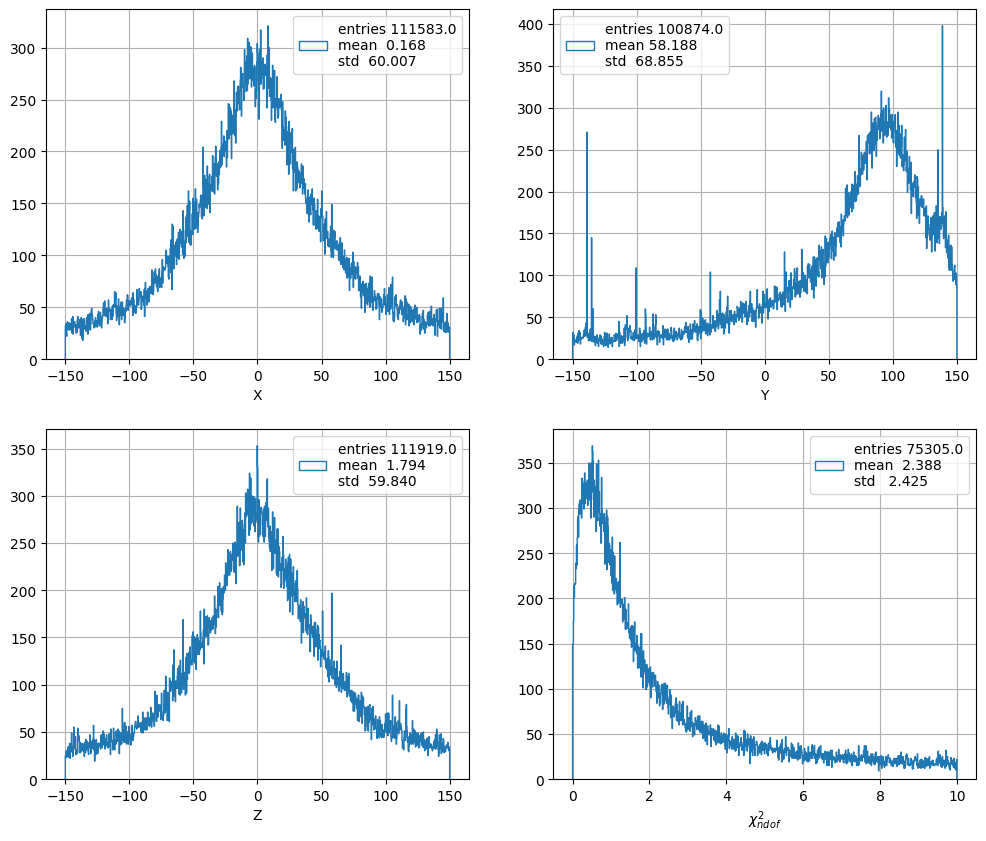

In [5]:
subplot = pltext.canvas(4)

subplot(1)
pltext.hist(df_reco["vertex_x"], 1000, stats=True, range=(-150,150), xylabels="X");

subplot(2)
pltext.hist(df_reco["vertex_y"], 1000, stats=True, range=(-150,150), xylabels="Y");

subplot(3)
pltext.hist(df_reco["vertex_z"], 1000, stats=True, range=(-150,150), xylabels="Z");

subplot(4)
pltext.hist(df_reco["chi2_ndof"], 1000, range=(0, 10), xylabels="$\chi^2_{ndof}$");

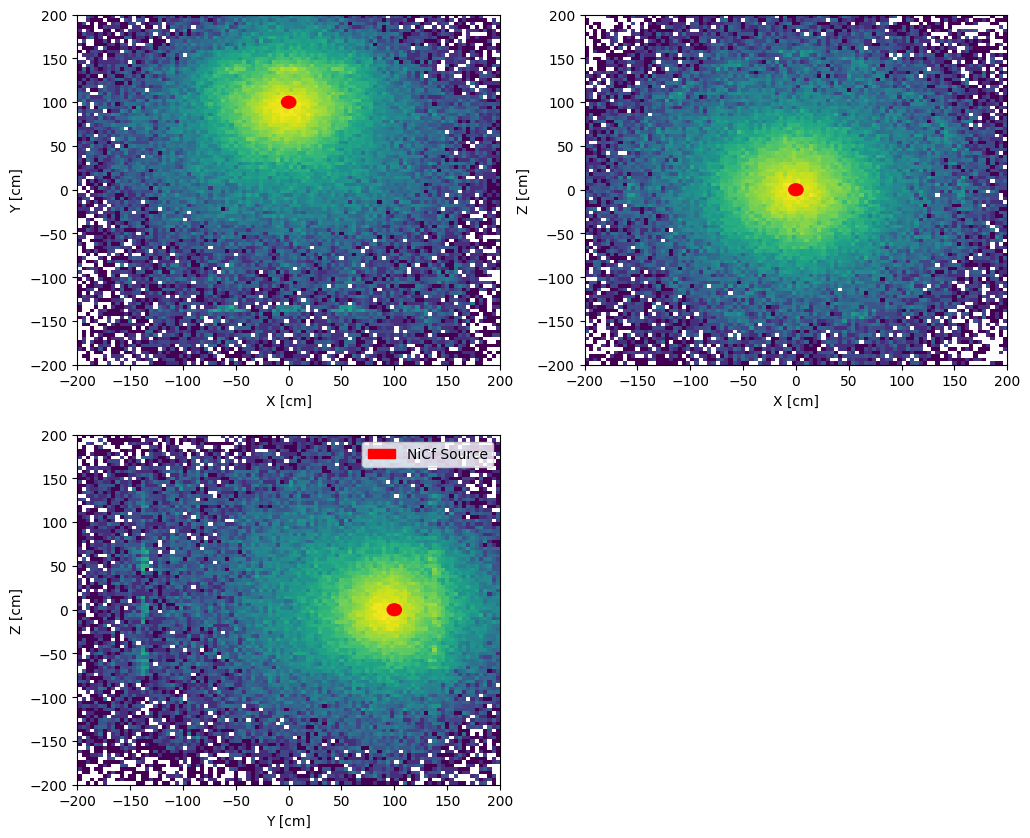

In [6]:
rho = 0
phi = 0
phi_prime = phi - np.pi/2
z   = 100

source_x = rho*np.cos(phi_prime)
source_z = rho*np.sin(phi_prime)
source_y = z
source_r = 6.75

subplot = pltext.canvas(3)

subplot(1)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_y"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_y), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("X [cm]")
plt.ylabel("Y [cm]")
subplot(2)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_z"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("X [cm]")
plt.ylabel("Z [cm]")
subplot(3)
plt.hist2d(df_reco["vertex_y"], df_reco["vertex_z"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_y, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("Y [cm]")
plt.ylabel("Z [cm]")

plt.legend();

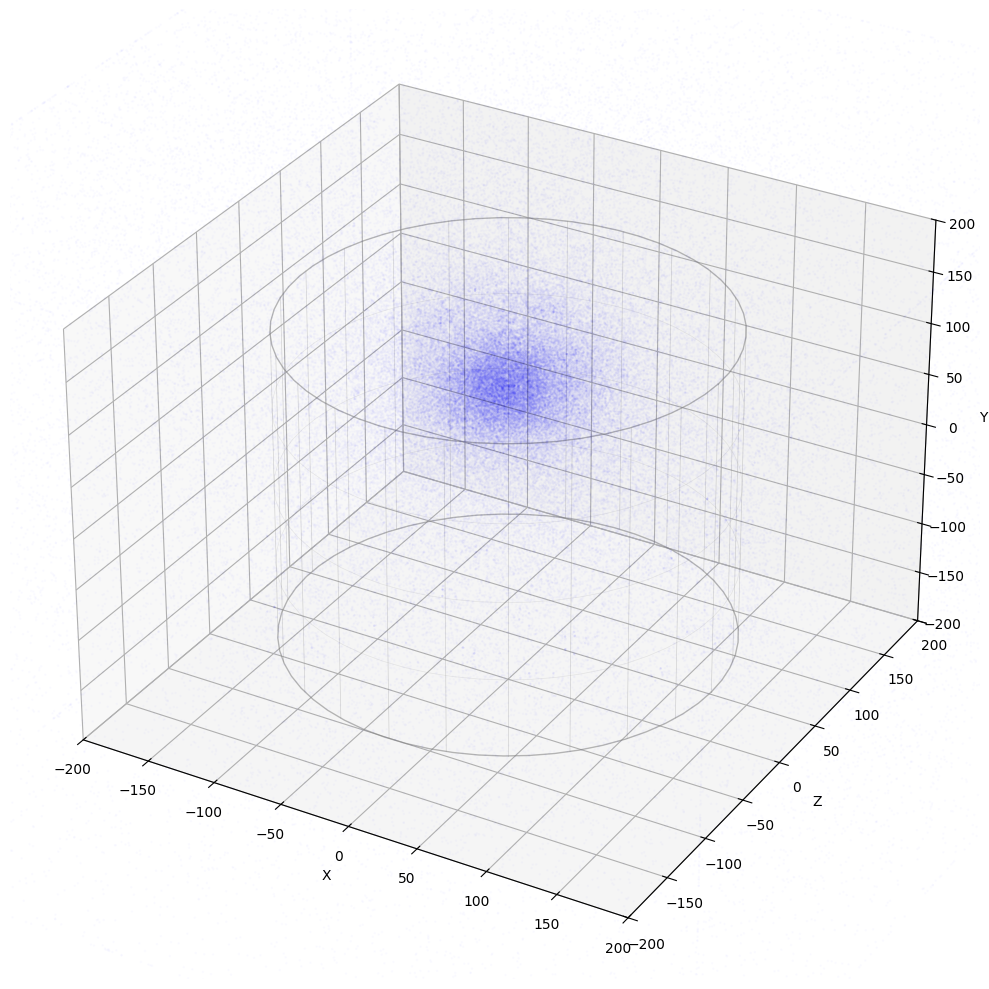

In [7]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# Vertices (swap Y<->Z for display)
ax.scatter(df_reco["vertex_x"], df_reco["vertex_z"], df_reco["vertex_y"], 
           alpha=0.01, color="blue", s=1)

theta = np.linspace(0, 2*np.pi, 60)
R = 150

# Barrel vertical lines (Y is vertical → plot as Z axis)
for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
    ax.plot([R*np.cos(angle)]*2, 
            [R*np.sin(angle)]*2,
            [-150, 150], 
            color='gray', alpha=0.3, linewidth=0.5)

# Top and bottom circles
for y_cap in [-150, 150]:
    ax.plot(R * np.cos(theta), 
            R * np.sin(theta),
            y_cap * np.ones_like(theta), 
            color='gray', alpha=0.5, linewidth=1)

# Horizontal rings
for y_ring in np.linspace(-150, 150, 5):
    ax.plot(R * np.cos(theta),
            R * np.sin(theta),
            y_ring * np.ones_like(theta),
            color='gray', alpha=0.15, linewidth=0.5)

ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_zlabel('Y')
ax.set_xlim(-200, 200); ax.set_ylim(-200, 200); ax.set_zlim(-200, 200)
plt.tight_layout()
plt.show()

/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/hipy/hipy/cfit.py:91: OptimizeWarning: Covariance of the parameters could not be estimated
  pars, fcov = optimize.curve_fit(cfun, x, y, p0 = cp0, sigma = sigma,


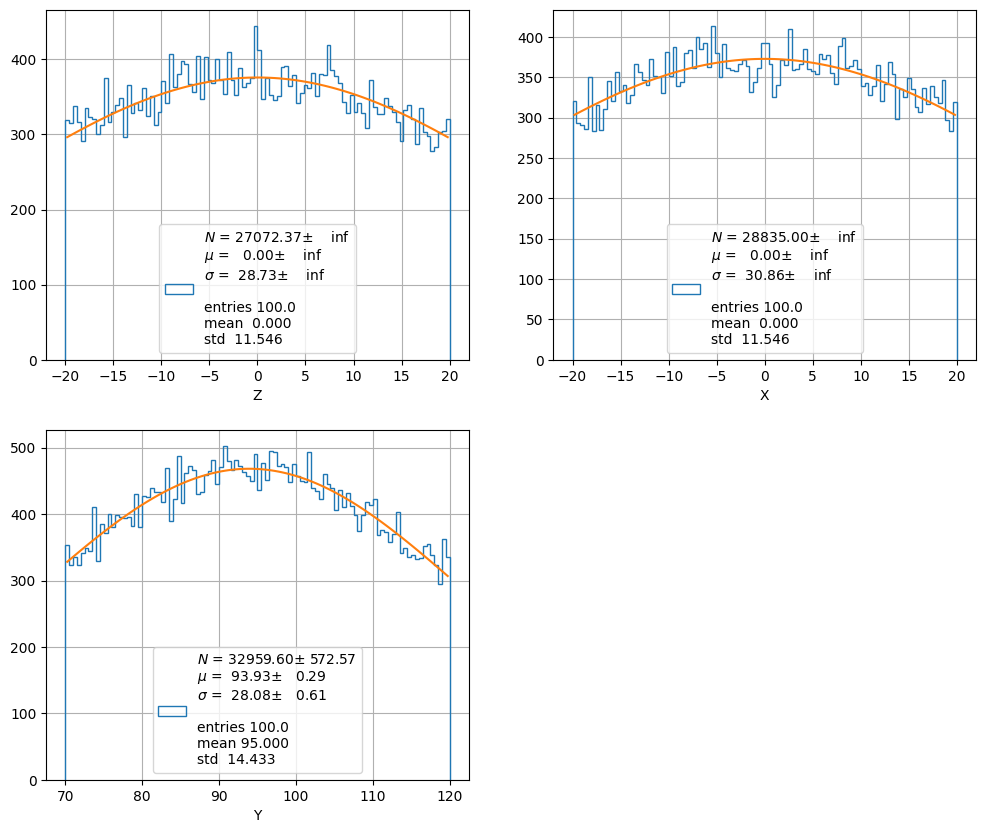

In [8]:
name= 'gaus'
nbins, size = 100, 120
data = df_reco

subplot = pltext.canvas(3)

subplot(1)
z_results = pltext.hfit(data["vertex_z"], nbins, name, xylabels="Z", stats = True, residuals = False, range=(-20,20));

subplot(2)
x_results = pltext.hfit(data["vertex_x"], nbins, name, xylabels="X", stats = True, residuals = False, range=(-20,20));

subplot(3)
y_results = pltext.hfit(data["vertex_y"], nbins, name, xylabels="Y", stats = True, residuals = False, range=(70,120));

# 1768

In [ ]:
# df_sig_1768 = pd.read_parquet("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1768/data/df_sig_R1768.parquet")

In [ ]:
# # --- Agrupar hits por candidato para el formato de Elena ---

# # Aplica corte de tRMS si quieres
# trms_cut = 6.0
# df_cut = df_sig_1768[df_sig_1768["trms"] < trms_cut]

# # Agrupar por candidato
# df_clusters = df_cut.groupby("candidate_id").agg(
#     event_id=("event_id", "first"),
#     hit_times_ns=("hit_pmt_calibrated_times_raw", list),
#     hit_slot_ids=("hit_mpmt_slot_ids", list),
#     hit_channel_ids=("hit_pmt_position_ids", list),
#     nhits=("hit_pmt_calibrated_times_raw", "count"),
#     trms=("trms", "first"),
# ).reset_index()

# # Filtrar candidatos con pocos hits (el código de Elena exige >= 6)
# df_clusters = df_clusters[df_clusters["nhits"] >= 6]

# print(f"Prepared {len(df_clusters)} candidates for reconstruction")

# # Guardar como CSV
# df_clusters.to_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1768/data/candidates_for_reco.csv", index=False)

In [ ]:
df_reco = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1768/data/candidates_for_reco_multilat_chi2.csv")

In [ ]:
subplot = pltext.canvas(4)

subplot(1)
pltext.hist(df_reco["vertex_x"], 1000, stats=True, range=(-150,150), xylabels="X");

subplot(2)
pltext.hist(df_reco["vertex_y"], 1000, stats=True, range=(-150,150), xylabels="Y");

subplot(3)
pltext.hist(df_reco["vertex_z"], 1000, stats=True, range=(-150,150), xylabels="Z");

subplot(4)
pltext.hist(df_reco["chi2_ndof"], 1000, range=(0, 10), xylabels="$\chi^2_{ndof}$");

In [ ]:
rho = 0
phi = 0
phi_prime = phi - np.pi/2
z   = 100

source_x = rho*np.cos(phi_prime)
source_z = rho*np.sin(phi_prime)
source_y = z
source_r = 6.75

subplot = pltext.canvas(3)

subplot(1)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_y"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_y), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("X [cm]")
plt.ylabel("Y [cm]")
subplot(2)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_z"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("X [cm]")
plt.ylabel("Z [cm]")
subplot(3)
plt.hist2d(df_reco["vertex_y"], df_reco["vertex_z"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_y, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("Y [cm]")
plt.ylabel("Z [cm]")

plt.legend();

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# Vertices (swap Y<->Z for display)
ax.scatter(df_reco["vertex_x"], df_reco["vertex_z"], df_reco["vertex_y"], 
           alpha=0.01, color="blue", s=1)

theta = np.linspace(0, 2*np.pi, 60)
R = 150

# Barrel vertical lines (Y is vertical → plot as Z axis)
for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
    ax.plot([R*np.cos(angle)]*2, 
            [R*np.sin(angle)]*2,
            [-150, 150], 
            color='gray', alpha=0.3, linewidth=0.5)

# Top and bottom circles
for y_cap in [-150, 150]:
    ax.plot(R * np.cos(theta), 
            R * np.sin(theta),
            y_cap * np.ones_like(theta), 
            color='gray', alpha=0.5, linewidth=1)

# Horizontal rings
for y_ring in np.linspace(-150, 150, 5):
    ax.plot(R * np.cos(theta),
            R * np.sin(theta),
            y_ring * np.ones_like(theta),
            color='gray', alpha=0.15, linewidth=0.5)

ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_zlabel('Y')
ax.set_xlim(-200, 200); ax.set_ylim(-200, 200); ax.set_zlim(-200, 200)
plt.tight_layout()
plt.show()

In [ ]:
name= 'gaus'
nbins, size = 100, 120
data = df_reco

subplot = pltext.canvas(3)

subplot(1)
z_results = pltext.hfit(data["vertex_z"], nbins, name, xylabels="Z", stats = True, residuals = False, range=(-20,20));

subplot(2)
x_results = pltext.hfit(data["vertex_x"], nbins, name, xylabels="X", stats = True, residuals = False, range=(-20,20));

subplot(3)
y_results = pltext.hfit(data["vertex_y"], nbins, name, xylabels="Y", stats = True, residuals = False, range=(70,120));

# 1769

In [ ]:
# df_sig_1769 = pd.read_parquet("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1769/data/df_sig_R1769.parquet")

In [ ]:
# # --- Agrupar hits por candidato para el formato de Elena ---

# # Aplica corte de tRMS si quieres
# trms_cut = 6.0
# df_cut = df_sig_1769[df_sig_1769["trms"] < trms_cut]

# # Agrupar por candidato
# df_clusters = df_cut.groupby("candidate_id").agg(
#     event_id=("event_id", "first"),
#     hit_times_ns=("hit_pmt_calibrated_times_raw", list),
#     hit_slot_ids=("hit_mpmt_slot_ids", list),
#     hit_channel_ids=("hit_pmt_position_ids", list),
#     nhits=("hit_pmt_calibrated_times_raw", "count"),
#     trms=("trms", "first"),
# ).reset_index()

# # Filtrar candidatos con pocos hits (el código de Elena exige >= 6)
# df_clusters = df_clusters[df_clusters["nhits"] >= 6]

# print(f"Prepared {len(df_clusters)} candidates for reconstruction")

# # Guardar como CSV
# df_clusters.to_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1769/data/candidates_for_reco.csv", index=False)

In [ ]:
df_reco = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1769/data/candidates_for_reco_multilat_chi2.csv")

In [ ]:
subplot = pltext.canvas(4)

subplot(1)
pltext.hist(df_reco["vertex_x"], 1000, stats=True, range=(-150,150), xylabels="X");

subplot(2)
pltext.hist(df_reco["vertex_y"], 1000, stats=True, range=(-150,150), xylabels="Y");

subplot(3)
pltext.hist(df_reco["vertex_z"], 1000, stats=True, range=(-150,150), xylabels="Z");

subplot(4)
pltext.hist(df_reco["chi2_ndof"], 1000, range=(0, 10), xylabels="$\chi^2_{ndof}$");

In [ ]:
rho = 110
phi = 135 #* np.pi/180
phi_prime = phi - np.pi/2
z   = 0

source_x = rho*np.cos(phi_prime)
source_z = rho*np.sin(phi_prime)
source_y = z
source_r = 6.75

subplot = pltext.canvas(3)

subplot(1)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_y"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_y), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("X [cm]")
plt.ylabel("Y [cm]")
subplot(2)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_z"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("X [cm]")
plt.ylabel("Z [cm]")
subplot(3)
plt.hist2d(df_reco["vertex_y"], df_reco["vertex_z"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_y, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("Y [cm]")
plt.ylabel("Z [cm]")

plt.legend();

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# Vertices (swap Y<->Z for display)
ax.scatter(df_reco["vertex_x"], df_reco["vertex_z"], df_reco["vertex_y"], 
           alpha=0.01, color="blue", s=1)

theta = np.linspace(0, 2*np.pi, 60)
R = 150

# Barrel vertical lines (Y is vertical → plot as Z axis)
for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
    ax.plot([R*np.cos(angle)]*2, 
            [R*np.sin(angle)]*2,
            [-150, 150], 
            color='gray', alpha=0.3, linewidth=0.5)

# Top and bottom circles
for y_cap in [-150, 150]:
    ax.plot(R * np.cos(theta), 
            R * np.sin(theta),
            y_cap * np.ones_like(theta), 
            color='gray', alpha=0.5, linewidth=1)

# Horizontal rings
for y_ring in np.linspace(-150, 150, 5):
    ax.plot(R * np.cos(theta),
            R * np.sin(theta),
            y_ring * np.ones_like(theta),
            color='gray', alpha=0.15, linewidth=0.5)

ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_zlabel('Y')
ax.set_xlim(-200, 200); ax.set_ylim(-200, 200); ax.set_zlim(-200, 200)
plt.tight_layout()
plt.show()

In [ ]:
name= 'gaus'
nbins, size = 100, 120
data = df_reco

subplot = pltext.canvas(3)

subplot(1)
z_results = pltext.hfit(data["vertex_z"], nbins, name, xylabels="Z", stats = True, residuals = False, range=(100,135));

subplot(2)
x_results = pltext.hfit(data["vertex_x"], nbins, name, xylabels="X", stats = True, residuals = False, range=(-20,20));

subplot(3)
y_results = pltext.hfit(data["vertex_y"], nbins, name, xylabels="Y", stats = True, residuals = False, range=(-20,30));

# 1770

In [ ]:
# df_sig_1770 = pd.read_parquet("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1770/data/df_sig_R1770.parquet")

In [ ]:
# # --- Agrupar hits por candidato para el formato de Elena ---

# # Aplica corte de tRMS si quieres
# trms_cut = 6.0
# df_cut = df_sig_1770[df_sig_1770["trms"] < trms_cut]

# # Agrupar por candidato
# df_clusters = df_cut.groupby("candidate_id").agg(
#     event_id=("event_id", "first"),
#     hit_times_ns=("hit_pmt_calibrated_times_raw", list),
#     hit_slot_ids=("hit_mpmt_slot_ids", list),
#     hit_channel_ids=("hit_pmt_position_ids", list),
#     nhits=("hit_pmt_calibrated_times_raw", "count"),
#     trms=("trms", "first"),
# ).reset_index()

# # Filtrar candidatos con pocos hits (el código de Elena exige >= 6)
# df_clusters = df_clusters[df_clusters["nhits"] >= 6]

# print(f"Prepared {len(df_clusters)} candidates for reconstruction")

# # Guardar como CSV
# df_clusters.to_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1770/data/candidates_for_reco.csv", index=False)

In [ ]:
df_reco = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1770/data/candidates_for_reco_multilat_chi2.csv")

In [ ]:
subplot = pltext.canvas(4)

subplot(1)
pltext.hist(df_reco["vertex_x"], 1000, stats=True, range=(-150,150), xylabels="X");

subplot(2)
pltext.hist(df_reco["vertex_y"], 1000, stats=True, range=(-150,150), xylabels="Y");

subplot(3)
pltext.hist(df_reco["vertex_z"], 1000, stats=True, range=(-150,150), xylabels="Z");

subplot(4)
pltext.hist(df_reco["chi2_ndof"], 1000, range=(0, 10), xylabels="$\chi^2_{ndof}$");

In [ ]:
rho = 55
phi = 135 #* np.pi/180
phi_prime = phi - np.pi/2
z   = -130

source_x = rho*np.cos(phi_prime)
source_z = rho*np.sin(phi_prime)
source_y = z
source_r = 6.75

subplot = pltext.canvas(3)

subplot(1)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_y"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_y), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("X [cm]")
plt.ylabel("Y [cm]")
subplot(2)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_z"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("X [cm]")
plt.ylabel("Z [cm]")
subplot(3)
plt.hist2d(df_reco["vertex_y"], df_reco["vertex_z"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_y, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("Y [cm]")
plt.ylabel("Z [cm]")

plt.legend();

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# Vertices (swap Y<->Z for display)
ax.scatter(df_reco["vertex_x"], df_reco["vertex_z"], df_reco["vertex_y"], 
           alpha=0.01, color="blue", s=1)

theta = np.linspace(0, 2*np.pi, 60)
R = 150

# Barrel vertical lines (Y is vertical → plot as Z axis)
for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
    ax.plot([R*np.cos(angle)]*2, 
            [R*np.sin(angle)]*2,
            [-150, 150], 
            color='gray', alpha=0.3, linewidth=0.5)

# Top and bottom circles
for y_cap in [-150, 150]:
    ax.plot(R * np.cos(theta), 
            R * np.sin(theta),
            y_cap * np.ones_like(theta), 
            color='gray', alpha=0.5, linewidth=1)

# Horizontal rings
for y_ring in np.linspace(-150, 150, 5):
    ax.plot(R * np.cos(theta),
            R * np.sin(theta),
            y_ring * np.ones_like(theta),
            color='gray', alpha=0.15, linewidth=0.5)

ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_zlabel('Y')
ax.set_xlim(-200, 200); ax.set_ylim(-200, 200); ax.set_zlim(-200, 200)
plt.tight_layout()
plt.show()

In [ ]:
name= 'gaus'
nbins, size = 100, 120
data = df_reco

subplot = pltext.canvas(3)

subplot(1)
z_results = pltext.hfit(data["vertex_z"], nbins, name, xylabels="Z", stats = True, residuals = False, range=(30,80));

subplot(2)
x_results = pltext.hfit(data["vertex_x"], nbins, name, xylabels="X", stats = True, residuals = False, range=(-30,20));

subplot(3)
y_results = pltext.hfit(data["vertex_y"], nbins, name, xylabels="Y", stats = True, residuals = False, range=(-150,-130));

# 1771

In [ ]:
# df_sig_1771 = pd.read_parquet("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1771/data/df_sig_R1771.parquet")

In [ ]:
# # --- Agrupar hits por candidato para el formato de Elena ---

# # Aplica corte de tRMS si quieres
# trms_cut = 6.0
# df_cut = df_sig_1771[df_sig_1771["trms"] < trms_cut]

# # Agrupar por candidato
# df_clusters = df_cut.groupby("candidate_id").agg(
#     event_id=("event_id", "first"),
#     hit_times_ns=("hit_pmt_calibrated_times_raw", list),
#     hit_slot_ids=("hit_mpmt_slot_ids", list),
#     hit_channel_ids=("hit_pmt_position_ids", list),
#     nhits=("hit_pmt_calibrated_times_raw", "count"),
#     trms=("trms", "first"),
# ).reset_index()

# # Filtrar candidatos con pocos hits (el código de Elena exige >= 6)
# df_clusters = df_clusters[df_clusters["nhits"] >= 6]

# print(f"Prepared {len(df_clusters)} candidates for reconstruction")

# # Guardar como CSV
# df_clusters.to_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1771/data/candidates_for_reco.csv", index=False)

In [ ]:
df_reco = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1771/data/candidates_for_reco_multilat_chi2.csv")

In [ ]:
subplot = pltext.canvas(4)

subplot(1)
pltext.hist(df_reco["vertex_x"], 1000, stats=True, range=(-150,150), xylabels="X");

subplot(2)
pltext.hist(df_reco["vertex_y"], 1000, stats=True, range=(-150,150), xylabels="Y");

subplot(3)
pltext.hist(df_reco["vertex_z"], 1000, stats=True, range=(-150,150), xylabels="Z");

subplot(4)
pltext.hist(df_reco["chi2_ndof"], 1000, range=(0, 10), xylabels="$\chi^2_{ndof}$");

In [ ]:
rho = 100
phi = 135 #* np.pi/180
phi_prime = phi - np.pi/2
z   = -130

source_x = rho*np.cos(phi_prime)
source_z = rho*np.sin(phi_prime)
source_y = z
source_r = 6.75

subplot = pltext.canvas(3)

subplot(1)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_y"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_y), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("X [cm]")
plt.ylabel("Y [cm]")
subplot(2)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_z"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("X [cm]")
plt.ylabel("Z [cm]")
subplot(3)
plt.hist2d(df_reco["vertex_y"], df_reco["vertex_z"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_y, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.xlabel("Y [cm]")
plt.ylabel("Z [cm]")

plt.legend();

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# Vertices (swap Y<->Z for display)
ax.scatter(df_reco["vertex_x"], df_reco["vertex_z"], df_reco["vertex_y"], 
           alpha=0.01, color="blue", s=1)

theta = np.linspace(0, 2*np.pi, 60)
R = 150

# Barrel vertical lines (Y is vertical → plot as Z axis)
for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
    ax.plot([R*np.cos(angle)]*2, 
            [R*np.sin(angle)]*2,
            [-150, 150], 
            color='gray', alpha=0.3, linewidth=0.5)

# Top and bottom circles
for y_cap in [-150, 150]:
    ax.plot(R * np.cos(theta), 
            R * np.sin(theta),
            y_cap * np.ones_like(theta), 
            color='gray', alpha=0.5, linewidth=1)

# Horizontal rings
for y_ring in np.linspace(-150, 150, 5):
    ax.plot(R * np.cos(theta),
            R * np.sin(theta),
            y_ring * np.ones_like(theta),
            color='gray', alpha=0.15, linewidth=0.5)

ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_zlabel('Y')
ax.set_xlim(-200, 200); ax.set_ylim(-200, 200); ax.set_zlim(-200, 200)
plt.tight_layout()
plt.show()

In [ ]:
name= 'gaus'
nbins, size = 100, 120
data = df_reco

subplot = pltext.canvas(3)

subplot(1)
z_results = pltext.hfit(data["vertex_z"], nbins, name, xylabels="Z", stats = True, residuals = False, range=(50,100));

subplot(2)
x_results = pltext.hfit(data["vertex_x"], nbins, name, xylabels="X", stats = True, residuals = False, range=(-60,0));

subplot(3)
y_results = pltext.hfit(data["vertex_y"], nbins, name, xylabels="Y", stats = True, residuals = False, range=(-150,-130));

# 2336

In [ ]:
# df_sig_2336 = pd.read_parquet("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/2336/data/df_sig_R2336.parquet")

In [ ]:
# # --- Agrupar hits por candidato para el formato de Elena ---

# # Aplica corte de tRMS si quieres
# trms_cut = 6.0
# df_cut = df_sig_2336[df_sig_2336["trms"] < trms_cut]

# # Agrupar por candidato
# df_clusters = df_cut.groupby("candidate_id").agg(
#     event_id=("event_id", "first"),
#     hit_times_ns=("hit_pmt_calibrated_times_raw", list),
#     hit_slot_ids=("hit_mpmt_slot_ids", list),
#     hit_channel_ids=("hit_pmt_position_ids", list),
#     nhits=("hit_pmt_calibrated_times_raw", "count"),
#     trms=("trms", "first"),
# ).reset_index()

# # Filtrar candidatos con pocos hits (el código de Elena exige >= 6)
# df_clusters = df_clusters[df_clusters["nhits"] >= 6]

# print(f"Prepared {len(df_clusters)} candidates for reconstruction")

# # Guardar como CSV
# df_clusters.to_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/2336/data/candidates_for_reco.csv", index=False)

In [ ]:
df_reco = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/2336/data/candidates_for_reco_multilat_chi2.csv")

In [ ]:
subplot = pltext.canvas(4)

subplot(1)
pltext.hist(df_reco["vertex_x"], 1000, stats=True, range=(-150,150), xylabels="X [cm]");
plt.vlines(0, 0, 300, linestyles=":", colors="red", label="Source Position")
plt.legend();

subplot(2)
pltext.hist(df_reco["vertex_y"], 1000, stats=True, range=(-150,150), xylabels="Y [cm]");
plt.vlines((-5 - 42.5), 0, 300, linestyles=":", colors="red", label="Source Position")
plt.legend();

subplot(3)
pltext.hist(df_reco["vertex_z"], 1000, stats=True, range=(-150,150), xylabels="Z [cm]");
plt.vlines(50, 0, 300, linestyles=":", colors="red", label="Source Position")
plt.legend();

subplot(4)
pltext.hist(df_reco["chi2_ndof"], 1000, range=(0, 10), xylabels="$\chi^2_{ndof}$");
plt.legend();

In [ ]:
rho = 50
phi = (-135 + 135) * np.pi/180
phi_prime = phi
z   = -50

source_x = rho*np.sin(phi_prime)
source_z = rho*np.cos(phi_prime)
source_y = z
source_r = 6.75

subplot = pltext.canvas(3)

subplot(1)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_y"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_y), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.vlines(0, -200, 200, linestyles="--", colors="k")
plt.hlines(0, -200, 200, linestyles="--", colors="k")
plt.xlabel("X [cm]")
plt.ylabel("Y [cm]")
subplot(2)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_z"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.vlines(0, -200, 200, linestyles="--", colors="k")
plt.hlines(0, -200, 200, linestyles="--", colors="k")
plt.xlabel("X [cm]")
plt.ylabel("Z [cm]")
subplot(3)
plt.hist2d(df_reco["vertex_z"], df_reco["vertex_y"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_z, source_y), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.vlines(0, -200, 200, linestyles="--", colors="k")
plt.hlines(0, -200, 200, linestyles="--", colors="k")
plt.xlabel("Z [cm]")
plt.ylabel("Y [cm]");

# plt.legend();

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# Vertices (swap Y<->Z for display)
ax.scatter(df_reco["vertex_x"], df_reco["vertex_z"], df_reco["vertex_y"], 
           alpha=0.01, color="blue", s=1)

theta = np.linspace(0, 2*np.pi, 60)
R = 150

# Barrel vertical lines (Y is vertical → plot as Z axis)
for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
    ax.plot([R*np.cos(angle)]*2, 
            [R*np.sin(angle)]*2,
            [-150, 150], 
            color='gray', alpha=0.3, linewidth=0.5)

# Top and bottom circles
for y_cap in [-150, 150]:
    ax.plot(R * np.cos(theta), 
            R * np.sin(theta),
            y_cap * np.ones_like(theta), 
            color='gray', alpha=0.5, linewidth=1)

# Horizontal rings
for y_ring in np.linspace(-150, 150, 5):
    ax.plot(R * np.cos(theta),
            R * np.sin(theta),
            y_ring * np.ones_like(theta),
            color='gray', alpha=0.15, linewidth=0.5)

ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_zlabel('Y')
ax.set_xlim(-200, 200); ax.set_ylim(-200, 200); ax.set_zlim(-200, 200)
plt.tight_layout()
plt.show()

In [ ]:
name= 'gaus'
nbins, size = 100, 120
data = df_reco

subplot = pltext.canvas(3)

subplot(1)
z_results = pltext.hfit(data["vertex_z"], nbins, name, xylabels="Z", stats = True, residuals = False, range=(30,85));

subplot(2)
x_results = pltext.hfit(data["vertex_x"], nbins, name, xylabels="X", stats = True, residuals = False, range=(-20,20));

subplot(3)
y_results = pltext.hfit(data["vertex_y"], nbins, name, xylabels="Y", stats = True, residuals = False, range=(-65,-25));

# 2337

In [ ]:
# df_sig_2337 = pd.read_parquet("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/2337/data/df_sig_R2337.parquet")

In [ ]:
# # --- Agrupar hits por candidato para el formato de Elena ---

# # Aplica corte de tRMS si quieres
# trms_cut = 6.0
# df_cut = df_sig_2337[df_sig_2337["trms"] < trms_cut]

# # Agrupar por candidato
# df_clusters = df_cut.groupby("candidate_id").agg(
#     event_id=("event_id", "first"),
#     hit_times_ns=("hit_pmt_calibrated_times_raw", list),
#     hit_slot_ids=("hit_mpmt_slot_ids", list),
#     hit_channel_ids=("hit_pmt_position_ids", list),
#     nhits=("hit_pmt_calibrated_times_raw", "count"),
#     trms=("trms", "first"),
# ).reset_index()

# # Filtrar candidatos con pocos hits (el código de Elena exige >= 6)
# df_clusters = df_clusters[df_clusters["nhits"] >= 6]

# print(f"Prepared {len(df_clusters)} candidates for reconstruction")

# # Guardar como CSV
# df_clusters.to_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/2337/data/candidates_for_reco.csv", index=False)

In [2]:
df_reco = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/2337/data/candidates_for_reco_multilat_chi2.csv")

In [ ]:
subplot = pltext.canvas(4)

subplot(1)
pltext.hist(df_reco["vertex_x"], 1000, stats=True, range=(-150,150), xylabels="X [cm]");
plt.vlines(-43.3, 0, 500, linestyles=":", colors="red", label="Source Position")
plt.legend();

subplot(2)
pltext.hist(df_reco["vertex_y"], 1000, stats=True, range=(-150,150), xylabels="Y [cm]");
plt.vlines((-5 - 42.5), 0, 500, linestyles=":", colors="red", label="Source Position")
plt.legend();

subplot(3)
pltext.hist(df_reco["vertex_z"], 1000, stats=True, range=(-150,150), xylabels="Z [cm]");
plt.vlines(25, 0, 500, linestyles=":", colors="red", label="Source Position")
plt.legend();

subplot(4)
pltext.hist(df_reco["chi2_ndof"], 1000, range=(0, 10), xylabels="$\chi^2_{ndof}$");
plt.legend();

In [ ]:
rho = 50
phi = (75 - 135) * np.pi/180
phi_prime = phi
z   = -50

source_x = rho*np.sin(phi_prime)
source_z = rho*np.cos(phi_prime)
source_y = z
source_r = 6.75

subplot = pltext.canvas(3)

subplot(1)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_y"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_y), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.vlines(0, -200, 200, linestyles="--", colors="k")
plt.hlines(0, -200, 200, linestyles="--", colors="k")
plt.xlabel("X [cm]")
plt.ylabel("Y [cm]")
subplot(2)
plt.hist2d(df_reco["vertex_x"], df_reco["vertex_z"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_x, source_z), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.vlines(0, -200, 200, linestyles="--", colors="k")
plt.hlines(0, -200, 200, linestyles="--", colors="k")
plt.xlabel("X [cm]")
plt.ylabel("Z [cm]")
subplot(3)
plt.hist2d(df_reco["vertex_z"], df_reco["vertex_y"], (100,100), norm="log", range=((-200,200),(-200,200)));
circle = plt.Circle((source_z, source_y), source_r, color='r', label="NiCf Source");
plt.gca().add_patch(circle)
plt.vlines(0, -200, 200, linestyles="--", colors="k")
plt.hlines(0, -200, 200, linestyles="--", colors="k")
plt.xlabel("Z [cm]")
plt.ylabel("Y [cm]");

# plt.legend();

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# Vertices (swap Y<->Z for display)
ax.scatter(df_reco["vertex_x"], df_reco["vertex_z"], df_reco["vertex_y"], 
           alpha=0.01, color="blue", s=1)

theta = np.linspace(0, 2*np.pi, 60)
R = 150

# Barrel vertical lines (Y is vertical → plot as Z axis)
for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
    ax.plot([R*np.cos(angle)]*2, 
            [R*np.sin(angle)]*2,
            [-150, 150], 
            color='gray', alpha=0.3, linewidth=0.5)

# Top and bottom circles
for y_cap in [-150, 150]:
    ax.plot(R * np.cos(theta), 
            R * np.sin(theta),
            y_cap * np.ones_like(theta), 
            color='gray', alpha=0.5, linewidth=1)

# Horizontal rings
for y_ring in np.linspace(-150, 150, 5):
    ax.plot(R * np.cos(theta),
            R * np.sin(theta),
            y_ring * np.ones_like(theta),
            color='gray', alpha=0.15, linewidth=0.5)

ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_zlabel('Y')
ax.set_xlim(-200, 200); ax.set_ylim(-200, 200); ax.set_zlim(-200, 200)
plt.tight_layout()
plt.show()

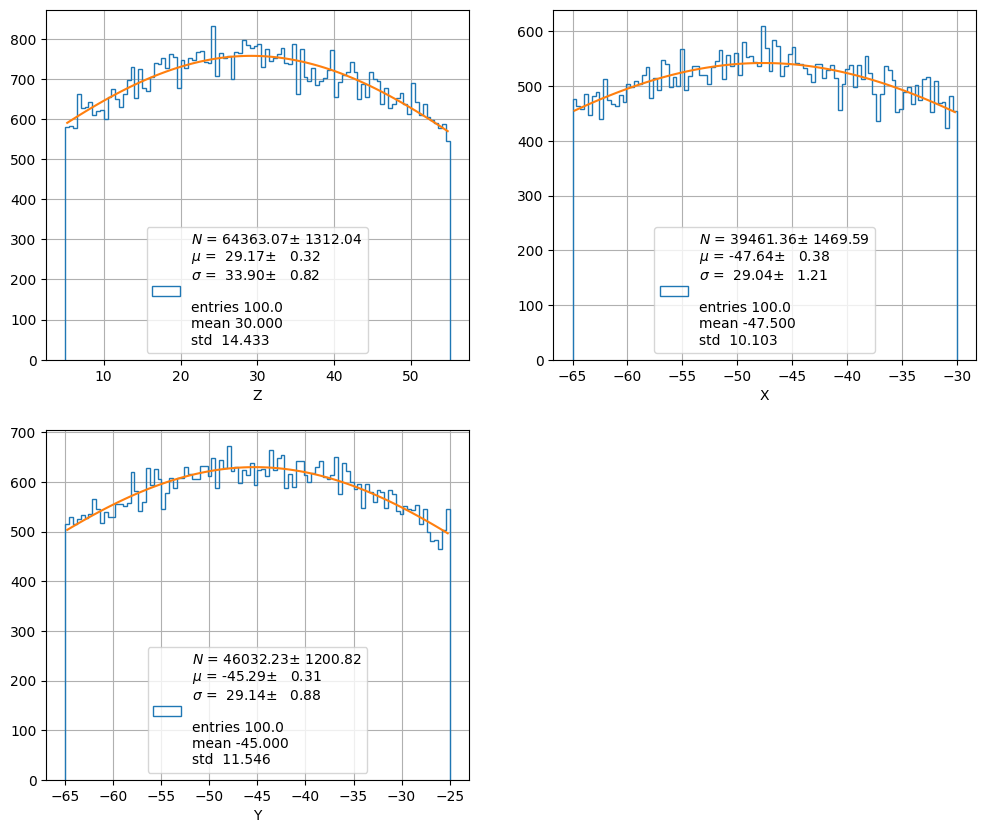

In [3]:
name= 'gaus'
nbins, size = 100, 120
data = df_reco

subplot = pltext.canvas(3)

subplot(1)
z_results = pltext.hfit(data["vertex_z"], nbins, name, xylabels="Z", stats = True, residuals = False, range=(5,55));

subplot(2)
x_results = pltext.hfit(data["vertex_x"], nbins, name, xylabels="X", stats = True, residuals = False, range=(-65,-30));

subplot(3)
y_results = pltext.hfit(data["vertex_y"], nbins, name, xylabels="Y", stats = True, residuals = False, range=(-65,-25));